# Adversarial attack with art

Simple white box attack implementation

In [1]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(".."))
sys.path.append(parent_dir)

In [2]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from utils.cnn_architecture import SimpleCNN
from utils.data_transformation import transform
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import FastGradientMethod

/home/adavodet/PROJECTS/cifar_classification/cifar_env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Load the data

In [4]:
img = Image.open('../data/cat.jpg')
img = transform(img)
img = img.unsqueeze(0)
img = img.to(device)

### Load the model

In [ ]:
# Basic model
# model = torch.load('../models/cifar10_basic_model.pth')

# Robust model
model = torch.load('../models/adversarially_trained_model.pth')

In [5]:
model.to(device)
model.eval()

/tmp/ipykernel_4044500/773149138.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('../models/adversarially_trained_model.pth')


SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
)

### Attack implementation

In [6]:
# CIFAR-10 class names
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [7]:
criterion = nn.CrossEntropyLoss()
classifier = PyTorchClassifier(model=model, loss=criterion, input_shape=(3, 32, 32), nb_classes=10)

In [8]:
attack = FastGradientMethod(estimator=classifier, eps=0.1)
img_numpy = img.cpu().detach().numpy()
adversarial_image = attack.generate(x=img_numpy)

In [9]:
adversarial_image_tensor = torch.tensor(adversarial_image).to(device)

In [10]:
with torch.no_grad():
    # Prediction on the original image
    original_pred = model(img).argmax(dim=1).item()

    # Prediction on the adversarial image
    adversarial_pred = model(adversarial_image_tensor).argmax(dim=1).item()

In [11]:
original_class_name = CIFAR10_CLASSES[original_pred]
adversarial_class_name = CIFAR10_CLASSES[adversarial_pred]

print(f"Prediction on original image: {original_pred} ({original_class_name})")
print(f"Prediction on adversarial image: {adversarial_pred} ({adversarial_class_name})")

Prediction on original image: 3 (cat)
Prediction on adversarial image: 3 (cat)


### Plot the results

In [12]:
def denormalize(img, mean, std):
    # Function to denormalize the image (undo normalization)
    img = img.clone()
    for i in range(img.shape[0]):
        img[i] = img[i] * std[i] + mean[i]
    return img

In [13]:
def resize_for_plotting(image_tensor, size=(224, 224)):
# Function to resize image for visualization purposes
    resize_transform = transforms.Resize(size)
    return resize_transform(image_tensor)

In [14]:
def plot_images(original_image, adversarial_image, original_class, adversarial_class):
    mean = [0.4914, 0.4822, 0.4465]
    std = [0.2470, 0.2435, 0.2616]

In [15]:
def plot_images(original_image, adversarial_image, original_class, adversarial_class):
    mean = [0.4914, 0.4822, 0.4465]
    std = [0.2470, 0.2435, 0.2616]

    original_image = denormalize(original_image.squeeze(0).cpu(), mean, std)
    adversarial_image = denormalize(adversarial_image.squeeze(0).cpu(), mean, std)

    original_image_resized = resize_for_plotting(original_image)
    adversarial_image_resized = resize_for_plotting(adversarial_image)

    original_image_resized = np.transpose(original_image_resized.numpy(), (1, 2, 0))
    adversarial_image_resized = np.transpose(adversarial_image_resized.numpy(), (1, 2, 0))

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Plot original image
    axes[0].imshow(original_image_resized)
    axes[0].set_title(f'Original Image - {original_class}', fontsize=14)
    axes[0].axis('off')

    # Plot adversarial image
    axes[1].imshow(adversarial_image_resized)
    axes[1].set_title(f'Adversarial Image - {adversarial_class}', fontsize=14)
    axes[1].axis('off')

    fig.suptitle('Original vs Adversarial Image', fontsize=16)
    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


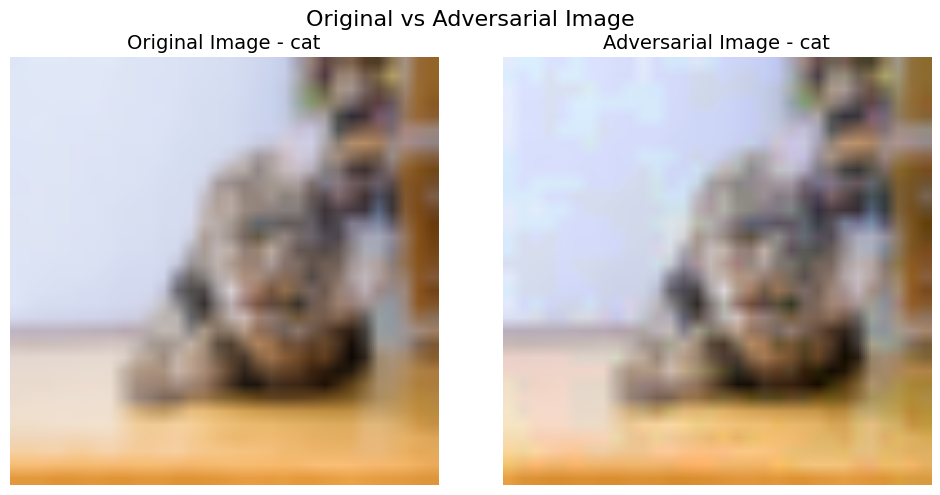

In [16]:
plot_images(img, adversarial_image_tensor, original_class_name, adversarial_class_name)